# [New York City]

## Preparation

- Number of words: 1490

- Runtime: Under 1 hour (*Memory 10 GB, CPU Intel i7-10700 CPU @2.90GHz*)

- Coding environment: SDS Docker 

- License: this notebook is made available under the [Creative Commons Attribution license](https://creativecommons.org/licenses/by/4.0/) (or other license that you like).

- Additional library *[libraries not included in SDS Docker or not used in this module]*:
    - **watermark**: A Jupyter Notebook extension for printing timestamps, version numbers, and hardware information.
   

## Table of contents

1. [Introduction](#Introduction)

2. [Research questions](#Research-questions)

3. [Data](#Data)

4. [Methodology](#Methodology)

5. [Results and discussion](#Results-and-discussion)

6. [Conclusion](#Conclusion)

7. [References](#References)

## 1. Introduction

[[ go back to the top ]](#Table-of-contents)

The United States is facing a deepening primary care crisis. As of 2025, over 92 million Americans, roughly 27% of the population, live in designated Health Professional Shortage Areas, and HRSA projects a national shortfall of over 70,000 full-time equivalent primary care physicians by 2038 (HRSA, 2025). This shortage is unevenly distributed. It follows socioeconomic fault lines, concentrating in communities where poverty, low insurance coverage, and inadequate infrastructure already compound health disadvantage.

New York City renders this crisis visible at a neighbourhood scale. Despite healthcare being the city's largest employment sector, Manhattan has double the healthcare workers per 100 residents compared to the Bronx, Queens, and Staten Island, and only 52% of the city's roughly 450 primary care facilities are located outside Manhattan and Brooklyn (NYCEDC, 2020). These imbalances cannot be explained by population size alone. Research consistently shows that income inequality is a stronger predictor of primary care shortage than absolute poverty levels (Shi et al., 1999). Socioeconomic barriers such as cost and neighbourhood deprivation determine whether residents can realistically access care, independent of whether a facility exists nearby (Kim et al., 2021).

Identifying which socioeconomic characteristics predict the spatial distribution of primary care deserts is of direct relevance to planners, public health agencies, and city government. Where deprivation reliably predicts scarcity, census data alone can flag at-risk districts before shortages escalate into health crises. This study employs Random Forest and Neural Network regression, combined with permutation importance and SHAP analysis, to address the following research question.

## 2. Research questions

[[ go back to the top ]](#Table-of-contents)

**To what extent do socioeconomic characteristics predict the spatial distribution of primary care deserts across New York City's community districts?**

## 3. Data

[[ go back to the top ]](#Table-of-contents)

### 3.1 Data Sources

Three datasets were used. The NYC Facilities Database provided facility locations and classifications across all five boroughs. Sociodemographic characteristics were drawn from the American Community Survey (ACS) 2019–2023 Five-Year Estimates at the Community District Tabulation Area level. District boundaries were obtained as a GeoJSON file containing NYC community district polygons provided by ArcGIS.

| Variable | Type | Description | Notes |
|---|---|---|---|
| `desert_score` | Numeric | Primary care desert score (0–1). **Dependent variable.** Higher = fewer facilities per capita = worse access. | Derived from NYC Facilities Database |
| `pct_elderly` | Numeric | % of population aged 65 and over | ACS Demographic file — `Pop65pl1P` |
| `median_income` | Numeric | Median household income (USD) | ACS Economic file — `MdHHIncE` |
| `pct_snap` | Numeric | % of households receiving SNAP (food stamps) | ACS Economic file — derived from `Inc_SNAPE` ÷ `Pop_1E` |
| `pop_density` | Numeric | Population per km² | Derived: `Pop_1E` ÷ district area in km² |

In [7]:
!pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 7.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.1/55.1 MB 34.3 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 40.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [shap]4/5 [shap]]te]


In [51]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
import shap

dem            = pd.read_excel('Dem_1923_CDTA.xlsx')
econ           = pd.read_excel('Econ_1923_CDTA.xlsx')
districts      = gpd.read_file('community_districts.geojson')
facilities_raw = pd.read_csv('nyc_facilities.csv', low_memory=False)

print('Dem:',       dem.shape)
print('Econ:',      econ.shape)
print('Districts:', districts.shape)
print('Facilities:', facilities_raw.shape)
print('\nDistrict columns:', districts.columns.tolist())
print('CRS:', districts.crs)
print('\nSample GeoIDs (ACS):', dem['GeoID'].head().tolist())
print('Sample BoroCD (GeoJSON):', districts['BoroCD'].head().tolist())
print('\nFacilities columns:', facilities_raw.columns.tolist())

Dem: (71, 535)
Econ: (71, 660)
Districts: (71, 3)
Facilities: (34708, 38)

District columns: ['OBJECTID', 'BoroCD', 'geometry']
CRS: EPSG:4326

Sample GeoIDs (ACS): ['BK01', 'BK02', 'BK03', 'BK04', 'BK05']
Sample BoroCD (GeoJSON): [410, 480, 483, 226, 313]

Facilities columns: ['uid', 'facname', 'addressnum', 'streetname', 'address', 'city', 'boro', 'borocode', 'zipcode', 'latitude', 'longitude', 'xcoord', 'ycoord', 'bin', 'bbl', 'cd', 'council', 'ct2010', 'ct2020', 'nta2010', 'nta2020', 'facgroup', 'facsubgrp', 'factype', 'capacity', 'captype', 'optype', 'opname', 'opabbrev', 'overlevel', 'overagency', 'overabbrev', 'datasource', 'facdomain', 'schooldist', 'policeprct', 'servarea', 'geometry']


### 3.2 Preprocessing 

The facilities database was filtered to primary care-relevant records using keyword matching across facility classification columns. Filtered facilities were spatially joined to community district polygons to produce a facility count per district. ACS demographic and economic files were merged on GeoID, constructed to align CDTA GeoIDs with numeric BoroCD codes. Facilities per 10,000 residents were calculated and transformed into the desert score, the dependent variable, by inverting and min-max normalising the ratio:

$$\text{Desert Score}_i = 1 - \frac{f_i - f_{\min}}{f_{\max} - f_{\min}}$$

where $f_i$ is the facilities per 10,000 residents in district $i$, and $f_{\min}$, $f_{\max}$ are the city-wide minimum and maximum of that ratio. A score of 1 indicates worst access and 0 the best. The final dataset comprised 62 community districts.

#### Filter primary care facilities:

In [49]:
# keywords target primary care facility types across all classification columns
# matching against factype, facsubgrp, facgroup, facdomain ensures broad coverage

domain_cols = [c for c in facilities_raw.columns
               if any(k in c.lower() for k in ['domain','group','type','sub'])]
print('Category columns found:', domain_cols)

for col in domain_cols[:2]:
    if col in facilities_raw.columns:
        print(f'\nTop values in [{col}]:')
        print(facilities_raw[col].value_counts().head(15))

Category columns found: ['facgroup', 'facsubgrp', 'factype', 'captype', 'optype', 'facdomain']

Top values in [facgroup]:
facgroup
YOUTH SERVICES                                   5267
DAY CARE AND PRE-KINDERGARTEN                    4296
TRANSPORTATION                                   3464
HEALTH CARE                                      3360
SCHOOLS (K-12)                                   3104
PARKS AND PLAZAS                                 2573
HUMAN SERVICES                                   2503
CULTURAL INSTITUTIONS                            2393
CHILD SERVICES AND WELFARE                       2068
SOLID WASTE                                      1695
HISTORICAL SITES                                 1083
OFFICES, TRAINING, AND TESTING                    528
VOCATIONAL AND PROPRIETARY SCHOOLS                465
CITY AGENCY PARKING, MAINTENANCE, AND STORAGE     413
CAMPS                                             324
Name: count, dtype: int64

Top values in [facsubgrp]:
facsu

#### Spatial join facilities:

In [25]:
PRIMARY_CARE_KEYWORDS = [
    'hospital', 'clinic', 'health center', 'health centre',
    'outpatient', 'federally qualified', 'fqhc',
    'primary care', 'community health', 'diagnostic'
]

def is_primary_care(row):
    for col in ['factype', 'facsubgrp', 'facgroup', 'facdomain']:
        if col in row.index and isinstance(row[col], str):
            if any(kw in row[col].lower() for kw in PRIMARY_CARE_KEYWORDS):
                return True
    return False

mask = facilities_raw.apply(is_primary_care, axis=1)
facilities_pc = facilities_raw[mask].copy()
print(f'Total facilities: {len(facilities_raw):,}')
print(f'Primary care filtered: {len(facilities_pc):,}')

# identify lat/lon columns
lat_col = next((c for c in facilities_pc.columns if c.lower() in ['latitude','lat','y']), None)
lon_col = next((c for c in facilities_pc.columns if c.lower() in ['longitude','lon','long','x']), None)
print(f'\nLat column: {lat_col} | Lon column: {lon_col}')

# remove records with missing coordinates or points outside NYC bounding box
# out-of-bounds points would cause incorrect district assignments in the spatial join
facilities_pc = facilities_pc.dropna(subset=[lat_col, lon_col])
facilities_pc = facilities_pc[
    facilities_pc[lon_col].between(-74.3, -73.7) &
    facilities_pc[lat_col].between(40.4, 40.95)
]

# convert to GeoDataFrame and spatial join
gdf_facilities = gpd.GeoDataFrame(
    facilities_pc,
    geometry=gpd.points_from_xy(facilities_pc[lon_col], facilities_pc[lat_col]),
    crs='EPSG:4326'
)
districts = districts.to_crs('EPSG:4326')

joined = gpd.sjoin(gdf_facilities, districts[['BoroCD','geometry']],
                   how='left', predicate='within')

facility_counts = joined.groupby('BoroCD').size().reset_index(name='facility_count')
print(f'\nDistricts with ≥1 facility: {len(facility_counts)}')
print(facility_counts.describe())

Total facilities: 34,708
Primary care filtered: 1,918

Lat column: latitude | Lon column: longitude

Districts with ≥1 facility: 59
           BoroCD  facility_count
count   59.000000       59.000000
mean   280.305085       31.694915
std    118.769010       15.845433
min    101.000000        8.000000
25%    203.500000       21.000000
50%    306.000000       28.000000
75%    402.500000       39.500000
max    503.000000       84.000000


#### Extract ACS features and build GeoID to BoroCD crosswalk:

In [26]:
# demographic features
dem_features = dem[['GeoID', 'GeogName', 'Borough',
                     'Pop_1E',    # total population
                     'Pop65pl1P', # % aged 65+
                     ]].copy()
dem_features.columns = ['GeoID', 'GeogName', 'Borough',
                         'total_pop', 'pct_elderly']

# economic features
econ_features = econ[['GeoID', 'MdHHIncE', 'Inc_SNAPE']].copy()
econ_features.columns = ['GeoID', 'median_income', 'snap_count']

# merge dem + econ
acs = dem_features.merge(econ_features, on='GeoID')
# normalise raw SNAP count by total population to make districts comparable
acs['pct_snap'] = (acs['snap_count'] / acs['total_pop'] * 100).round(2)

# GeoID → BoroCD crosswalk  (e.g. BK01 → 301, MN03 → 103)
prefix_map = {'MN': 100, 'BX': 200, 'BK': 300, 'QN': 400, 'SI': 500}

def geoid_to_borocd(geoid):
    prefix = geoid[:2]
    num    = int(geoid[2:])
    return prefix_map.get(prefix, np.nan) + num if prefix in prefix_map else np.nan

acs['BoroCD'] = acs['GeoID'].apply(geoid_to_borocd)
acs = acs.dropna(subset=['BoroCD'])
acs['BoroCD'] = acs['BoroCD'].astype(int)

print(f'ACS rows after crosswalk: {len(acs)}')
print(acs[['GeoID', 'BoroCD', 'total_pop', 'pct_elderly', 'median_income']].head(8).to_string())

ACS rows after crosswalk: 71
  GeoID  BoroCD  total_pop  pct_elderly  median_income
0  BK01     301     203002          9.2       102807.0
1  BK02     302     125637         12.5       145094.0
2  BK03     303     180283         10.3        77546.0
3  BK04     304     111975         10.4        83441.0
4  BK05     305     201036         14.6        54145.0
5  BK06     306     121009         12.2       165947.0
6  BK07     307     120253         12.7        84767.0
7  BK08     308     109719         12.6        90978.0


#### Merge ACS and facility counts onto district polygons:

In [50]:
df = acs.merge(facility_counts, on='BoroCD', how='left')
# districts with no matched facilities are assigned zero rather than dropped
df['facility_count'] = df['facility_count'].fillna(0)

gdf = districts.merge(df, on='BoroCD', how='inner')

# population density (requires projected CRS for accurate area in km²)
gdf_proj           = gdf.to_crs('EPSG:32618')    # UTM zone 18N – New York
gdf['area_km2']    = gdf_proj.geometry.area / 1e6
gdf['pop_density'] = gdf['total_pop'] / gdf['area_km2']

# facilities per 10,000 residents
gdf['facilities_per_10k'] = (
    gdf['facility_count'] / (gdf['total_pop'] / 10_000)
).round(4)

# Desert Score (target variable) 
# normalise facilities_per_10k to [0,1], then invert:
# desert_score = 1 → fewest facilities (worst access)
# desert_score = 0 → most facilities  (best access)
f = gdf['facilities_per_10k']
gdf['desert_score'] = 1 - (f - f.min()) / (f.max() - f.min())

print(f'Final modelling dataset: {gdf.shape}')
print(gdf[['GeogName', 'facilities_per_10k', 'desert_score',
           'pct_elderly', 'median_income', 'pct_snap',
           'pop_density']].head(10).to_string())

Final modelling dataset: (71, 16)
                                                   GeogName  facilities_per_10k  desert_score  pct_elderly  median_income  pct_snap   pop_density
0  QN10 South Ozone Park-Howard Beach (CD 10 Approximation)              0.7386      0.909224         18.5        94552.0      4.78   8474.335125
1             QN80 LaGuardia Airport (JIA 80 Approximation)                 NaN           NaN          NaN            NaN       NaN      0.000000
2     QN83 JFK International Airport (JIA 83 Approximation)                 NaN           NaN          NaN            NaN       NaN      0.000000
3               BX26 Van Cortlandt Park (JIA 26 Equivalent)              0.0000      1.000000          NaN       106249.0      0.00     11.927652
4    BK13 Coney Island-Brighton Beach (CD 13 Approximation)              2.0882      0.743354         26.4        45489.0     15.84  13440.588235
5   MN05 Midtown-Flatiron-Union Square (CD 5 Approximation)              8.1365      0.000

#### Mapping:

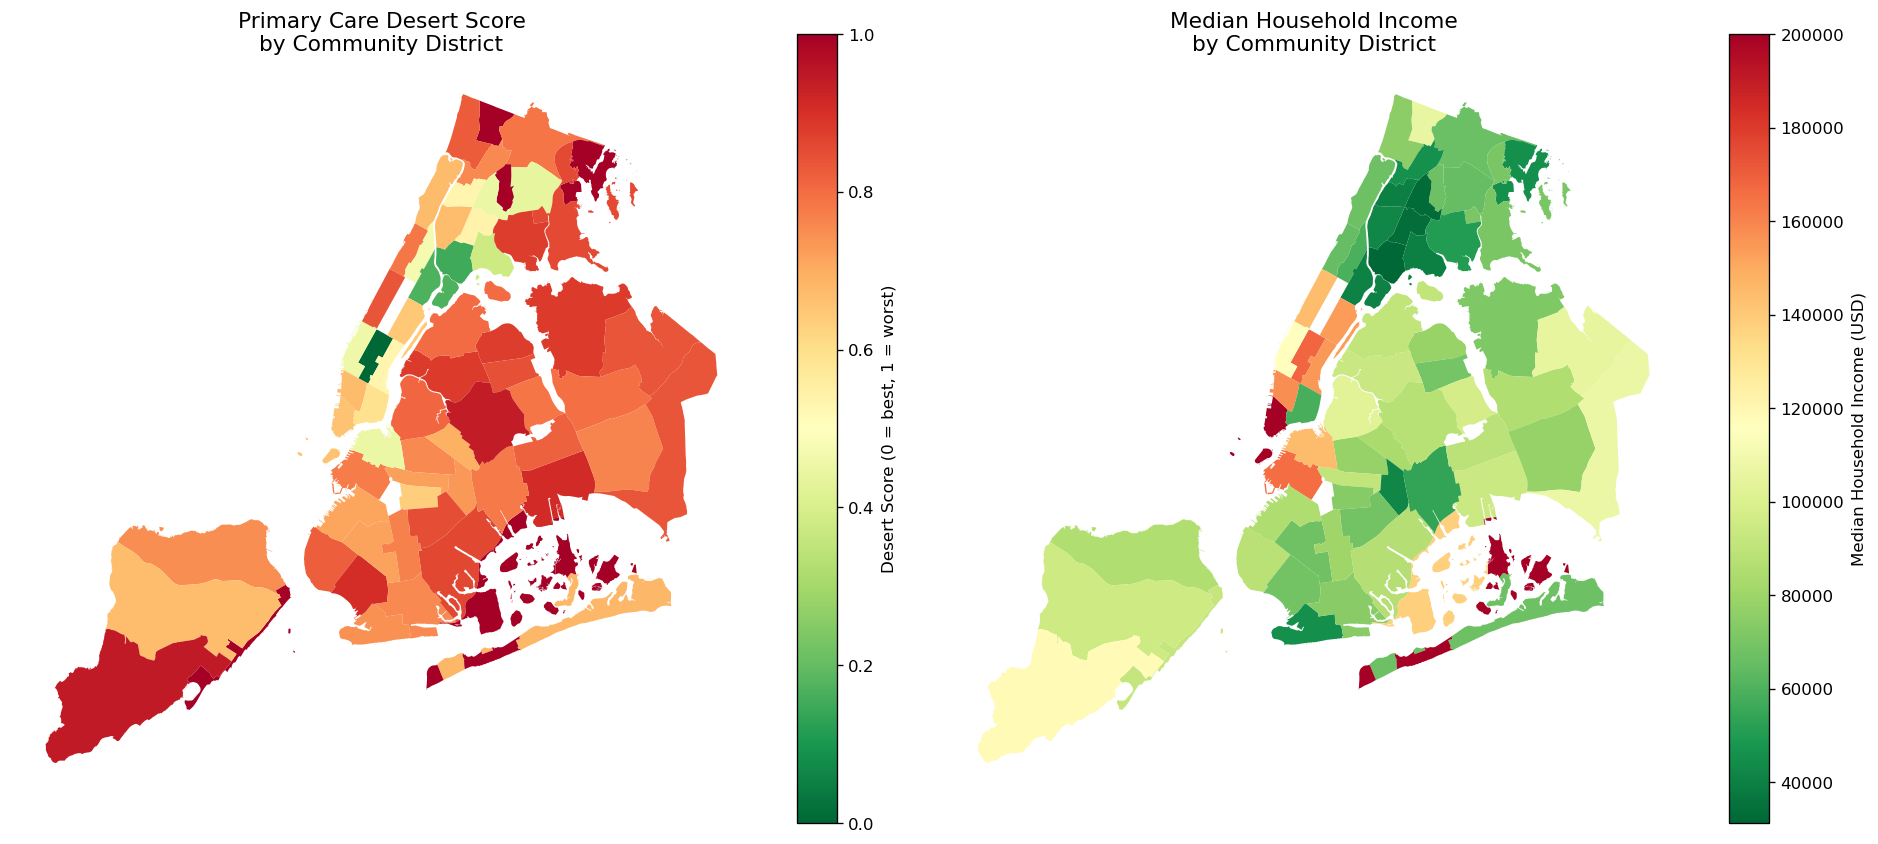

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: desert score — the dependent variable
gdf.plot(column='desert_score', ax=axes[0], legend=True, cmap='RdYlGn_r',
         legend_kwds={'label': 'Desert Score (0 = best, 1 = worst)'})
axes[0].set_title('Primary Care Desert Score\nby Community District', fontsize=13)
axes[0].axis('off')

# Right: median income — shown here because it is the strongest predictor
# of desert score across both permutation importance and SHAP analyses
gdf.plot(column='median_income', ax=axes[1], legend=True, cmap='RdYlGn_r',
         legend_kwds={'label': 'Median Household Income (USD)'})
axes[1].set_title('Median Household Income\nby Community District', fontsize=13)
axes[1].axis('off')

plt.tight_layout()
plt.show()

#### Correlation matrix:

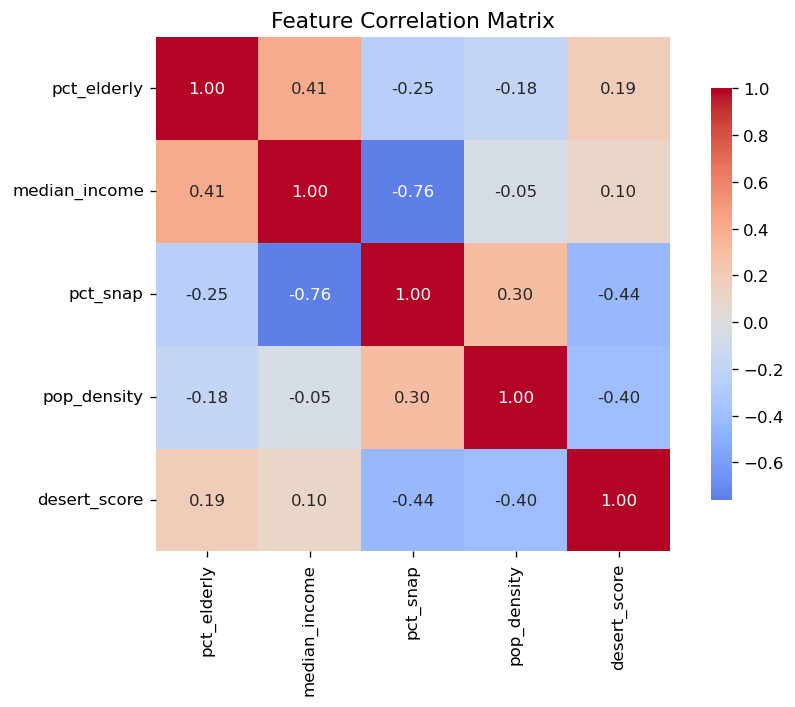

In [32]:
feature_cols = ['pct_elderly', 'median_income', 'pct_snap',
                'pop_density', 'desert_score']

corr = gdf[feature_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()

In [33]:
print(gdf.describe())
print(gdf.isna().sum())

        OBJECTID      BoroCD      total_pop  pct_elderly  median_income  \
count  71.000000   71.000000      71.000000    62.000000      65.000000   
mean   36.000000  297.169014  119946.507042    16.651613   86810.076923   
std    20.639767  127.266311   67386.413983    11.695841   39318.199834   
min     1.000000  101.000000       0.000000     1.800000   31296.000000   
25%    18.500000  205.500000   92417.000000    12.225000   65063.000000   
50%    36.000000  308.000000  125637.000000    15.350000   78398.000000   
75%    53.500000  405.500000  165280.500000    18.950000   97258.000000   
max    71.000000  595.000000  254693.000000   100.000000  200000.000000   

         snap_count   pct_snap  facility_count   area_km2   pop_density  \
count     71.000000  65.000000       71.000000  71.000000     71.000000   
mean    9419.169014   7.734154       26.338028  11.014228  15060.051990   
std     6988.224943   5.198740       18.738763  10.500172  11345.076279   
min        0.000000   0.

## 4. Methodology

[[ go back to the top ]](#Table-of-contents)

Supervised regression was the appropriate framework for the research question, as it directly models the relationship between sociodemographic inputs and a continuous outcome (Kuhn and Johnson, 2013). A continuous desert score was preferred over binary desert classification because it preserves spatial gradients of access inequality, enabling models to detect finer variation across districts rather than collapsing it into presence or absence.

Random Forest Regression was selected as the primary model for its robustness to non-linearity, multicollinearity, and small sample sizes (Breiman, 2001). It is well-suited to the districts available in New York City. A Neural Network Regression was included as a comparison model to assess whether capturing deeper non-linear interactions between sociodemographic features improves predictive accuracy beyond what an ensemble tree method achieves (Goodfellow et al., 2016). Both models were trained on an 80/20 train-test split and tuned via five-fold cross-validation, with performance evaluated using CV R², Train R², Test R², and MAE to assess predictive performance and identify overfitting (Kuhn and Johnson, 2013).
 
Two interpretability methods were applied to move beyond prediction toward explanation, which the research question requires. Permutation Feature Importance quantifies each feature's contribution to model performance by measuring the drop in R² when feature values are randomly shuffled, avoiding the upward bias of impurity-based importance in tree models (Molnar, 2022). SHAP analysis was additionally applied to the best-performing model to decompose each feature's directional contribution at the individual district level, revealing how and where their effects concentrate across the city (Lundberg and Lee, 2017). SHAP TreeExplainer is exact and computationally efficient for tree models; kernel-based SHAP for the MLP would be approximate and substantially slower on this dataset, so interpretation is focused on the Random Forest.

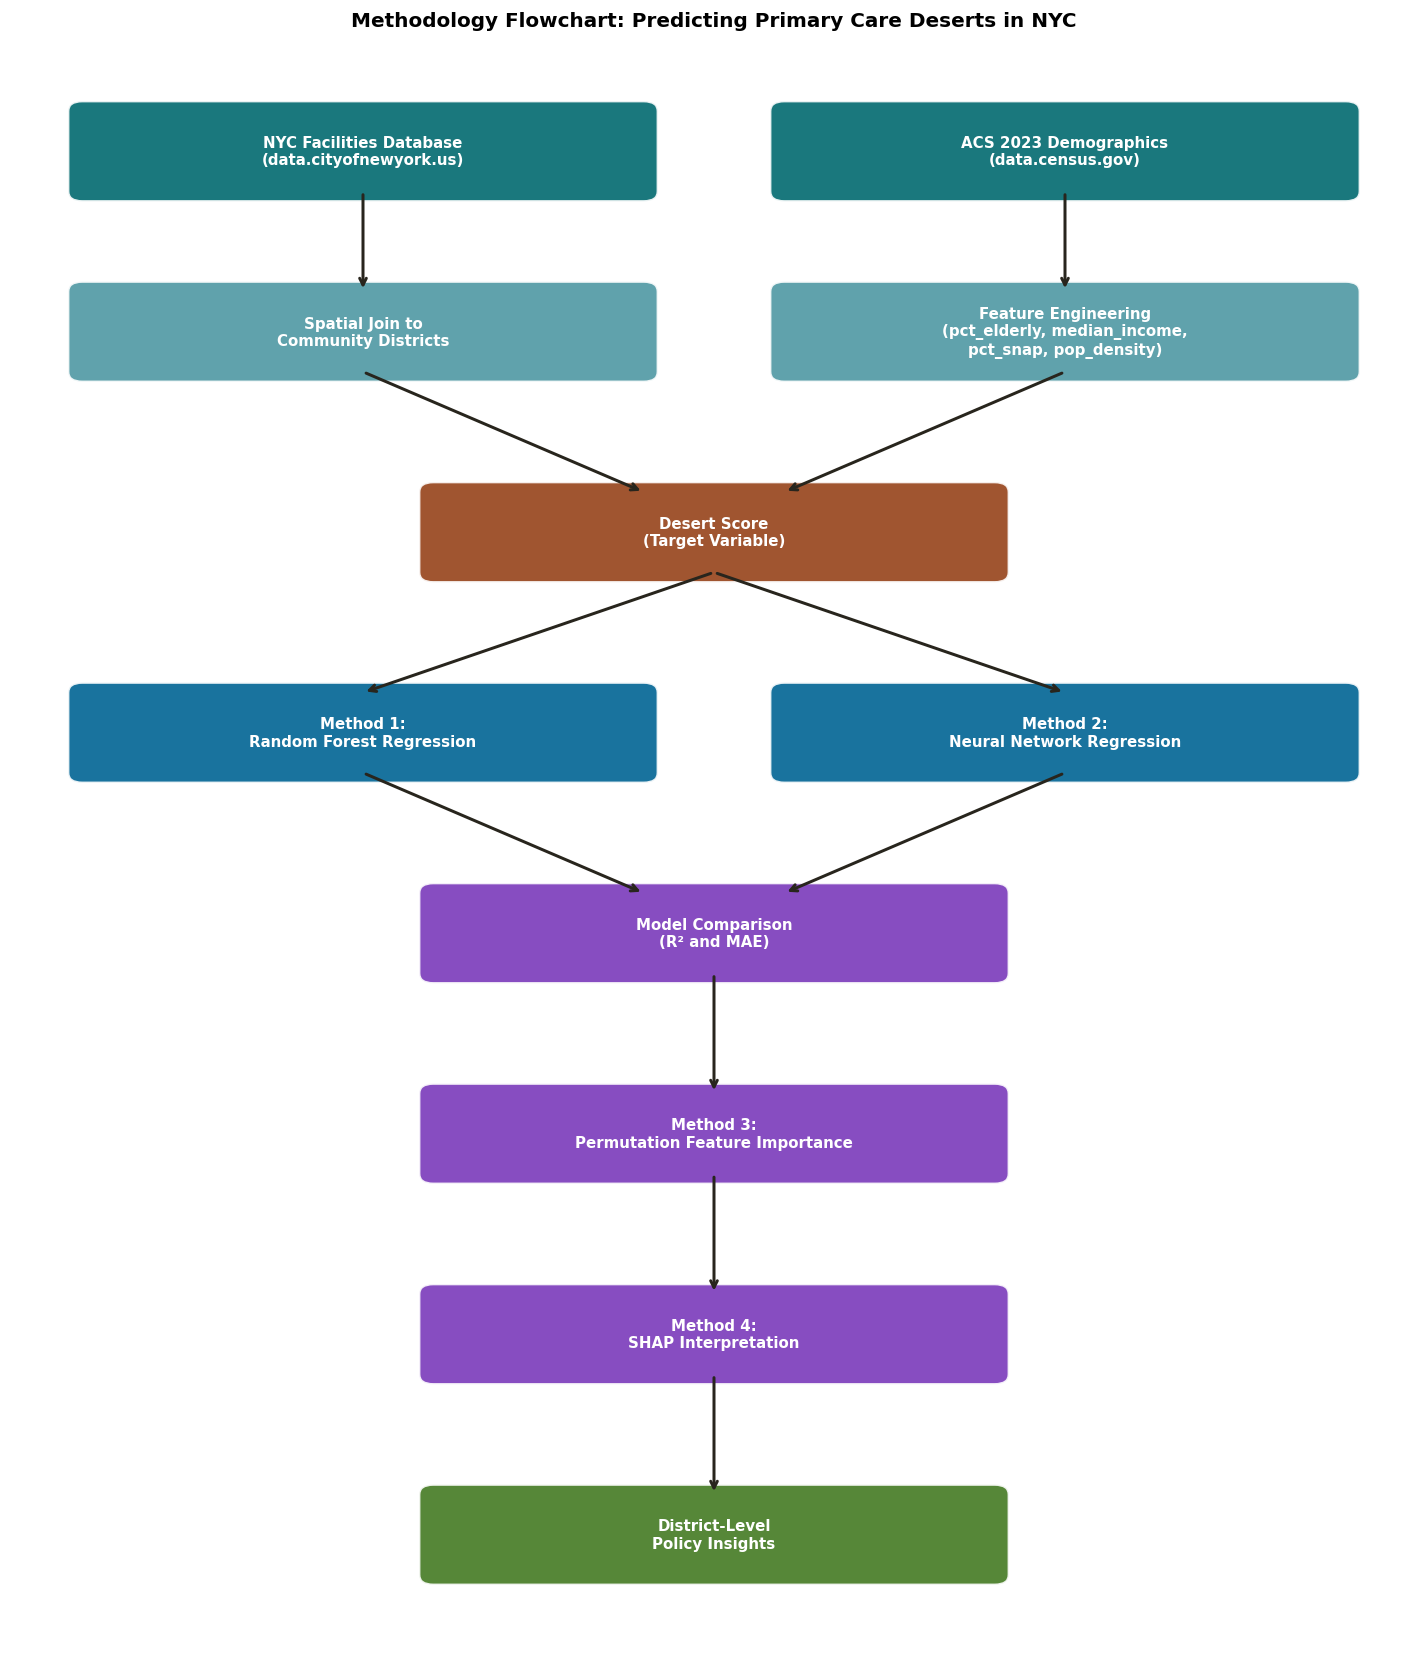

In [52]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(12, 14))
ax.set_xlim(0, 10)
ax.set_ylim(0, 16)
ax.axis('off')

def box(ax, x, y, w, h, text, color='#4f98a3'):
    fancy = FancyBboxPatch((x - w/2, y - h/2), w, h,
                            boxstyle="round,pad=0.1",
                            facecolor=color, edgecolor='white',
                            linewidth=1.5, alpha=0.9)
    ax.add_patch(fancy)
    ax.text(x, y, text, ha='center', va='center',
            fontsize=9, fontweight='bold', color='white', wrap=True,
            multialignment='center')

def arrow(ax, x1, y1, x2, y2):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color='#28251d', lw=1.8))

# Nodes
box(ax, 2.5, 15,   4, 0.8, 'NYC Facilities Database\n(data.cityofnewyork.us)', '#01696f')
box(ax, 7.5, 15,   4, 0.8, 'ACS 2023 Demographics\n(data.census.gov)',         '#01696f')
box(ax, 2.5, 13.2, 4, 0.8, 'Spatial Join to\nCommunity Districts',             '#4f98a3')
box(ax, 7.5, 13.2, 4, 0.8, 'Feature Engineering\n(pct_elderly, median_income,\npct_snap, pop_density)', '#4f98a3')
box(ax, 5,   11.2, 4, 0.8, 'Desert Score\n(Target Variable)',                   '#964219')
box(ax, 2.5,  9.2, 4, 0.8, 'Method 1:\nRandom Forest Regression',              '#006494')
box(ax, 7.5,  9.2, 4, 0.8, 'Method 2:\nNeural Network Regression',             '#006494')
box(ax, 5,    7.2, 4, 0.8, 'Model Comparison\n(R² and MAE)',                    '#7a39bb')
box(ax, 5,    5.2, 4, 0.8, 'Method 3:\nPermutation Feature Importance',         '#7a39bb')
box(ax, 5,    3.2, 4, 0.8, 'Method 4:\nSHAP Interpretation',                    '#7a39bb')
box(ax, 5,    1.2, 4, 0.8, 'District-Level\nPolicy Insights',                   '#437a22')

# Arrows
arrow(ax, 2.5, 14.6, 2.5, 13.6)
arrow(ax, 7.5, 14.6, 7.5, 13.6)
arrow(ax, 2.5, 12.8, 4.5, 11.6)
arrow(ax, 7.5, 12.8, 5.5, 11.6)
arrow(ax, 5,   10.8, 2.5,  9.6)
arrow(ax, 5,   10.8, 7.5,  9.6)
arrow(ax, 2.5,  8.8, 4.5,  7.6)
arrow(ax, 7.5,  8.8, 5.5,  7.6)
arrow(ax, 5,    6.8, 5,    5.6)
arrow(ax, 5,    4.8, 5,    3.6)
arrow(ax, 5,    2.8, 5,    1.6)

plt.title('Methodology Flowchart: Predicting Primary Care Deserts in NYC',
          fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('methodology_flowchart.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Results and discussion

[[ go back to the top ]](#Table-of-contents)

### 5.1 Set Up

In [47]:
FEATURES = ['pct_elderly', 'median_income', 'pct_snap', 'pop_density']
TARGET   = 'desert_score'

model_df = gdf[FEATURES + [TARGET]].dropna().reset_index(drop=True)
X = model_df[FEATURES].values
y = model_df[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# scale for neural network (RF does not need scaling)
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
X_all_sc   = scaler.transform(X)

print(f'Total districts: {len(model_df)}')
print(f'Train size: {len(X_train)} | Test size: {len(X_test)}')

Total districts: 62
Train size: 49 | Test size: 13


### 5.2 Method 1: Random Forest

In [40]:
# use cross validation to tune RandomForestRegressor
param_grid_rf = {
    'max_depth':        [None, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4],
    'max_features':     ['sqrt', 'log2', 0.5, 1.0]
}
grid_rf = GridSearchCV(
    estimator=RandomForestRegressor(n_estimators=500, random_state=42),
    param_grid=param_grid_rf,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    return_train_score=True
)
grid_rf.fit(X_train, y_train)

# print best hyperparameters and best CV R-squared
print("Best hyperparameters:", grid_rf.best_params_)
print(f"Best CV R-squared: {grid_rf.best_score_:.3f}")

# retrain with optimal hyperparameters
best_params_rf = grid_rf.best_params_
rf_best = RandomForestRegressor(n_estimators=500, random_state=42, **best_params_rf)
rf_best.fit(X_train, y_train)

# R2 on training and testing data
train_r2_rf = r2_score(y_train, rf_best.predict(X_train))
test_r2_rf  = r2_score(y_test,  rf_best.predict(X_test))
mae_rf      = mean_absolute_error(y_test, rf_best.predict(X_test))
print(f"Train R-squared: {train_r2_rf:.3f}")
print(f"Test  R-squared: {test_r2_rf:.3f}")
print(f"Test  MAE:       {mae_rf:.3f}")

# store results
rf_results = {
    'CV_R2':    grid_rf.best_score_,
    'Train_R2': train_r2_rf,
    'Test_R2':  test_r2_rf,
    'Test_MAE': mae_rf
}

Best hyperparameters: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 4}
Best CV R-squared: -0.107
Train R-squared: 0.513
Test  R-squared: 0.446
Test  MAE:       0.102


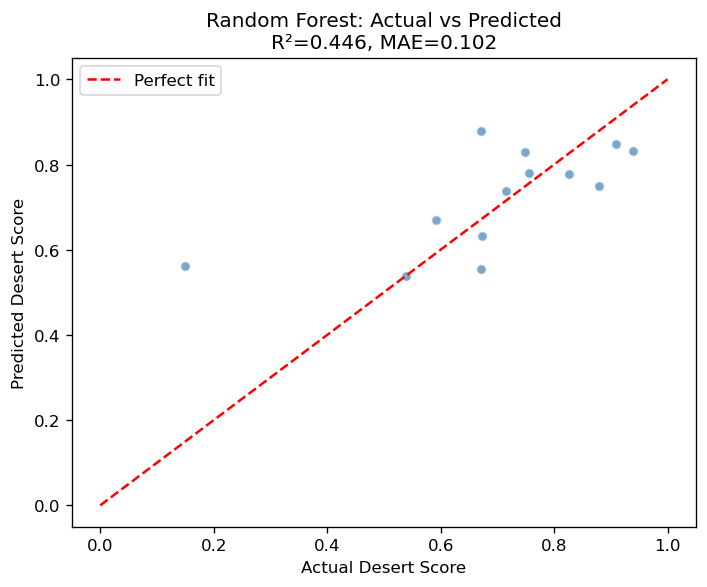

In [41]:
y_pred_rf = rf_best.predict(X_test)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y_test, y_pred_rf, alpha=0.7, edgecolors='white', color='steelblue')
ax.plot([0, 1], [0, 1], 'r--', lw=1.5, label='Perfect fit')
ax.set_xlabel('Actual Desert Score')
ax.set_ylabel('Predicted Desert Score')
ax.set_title(f'Random Forest: Actual vs Predicted\nR²={test_r2_rf:.3f}, MAE={mae_rf:.3f}')
ax.legend()
plt.tight_layout()
plt.savefig('rf_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

The Random Forest achieved a test R² of 0.446 and MAE of 0.102, explaining around 45% of variance in desert scores across held-out districts, with an average prediction error of 0.10 units on the 0 to 1 scale. The scatter plot shows a broadly positive trend, with most districts clustering toward the upper right. However, several points sit noticeably above the perfect fit line, suggesting the model underestimates scores in the most severely underserved districts. The best hyperparameters selected by grid search are printed in the output above; the shallow depth constraint helps prevent overfitting on the small 62-district dataset, though it also limits the model's ability to capture more complex relationships between features and desert scores. The shallow depth constraint helps prevent overfitting on the small 62-district dataset, though it also limits the model's ability to capture more complex relationships between features and desert scores.

### 5.3 Method 2: Neural Network

In [42]:
# use cross validation to tune MLPRegressor
param_grid_nn = {
    'hidden_layer_sizes': [(64, 32), (128, 64), (32,), (64,)],
    'activation':         ['relu', 'tanh'],
    'alpha':              [0.0001, 0.001, 0.01]
}
grid_nn = GridSearchCV(
    estimator=MLPRegressor(max_iter=2000, early_stopping=True, random_state=42),
    param_grid=param_grid_nn,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    return_train_score=True
)
grid_nn.fit(X_train_sc, y_train)

# print best hyperparameters and best CV R-squared
print("Best hyperparameters:", grid_nn.best_params_)
print(f"Best CV R-squared: {grid_nn.best_score_:.3f}")

# retrain with optimal hyperparameters
best_params_nn = grid_nn.best_params_
nn_best = MLPRegressor(max_iter=2000, early_stopping=True, random_state=42, **best_params_nn)
nn_best.fit(X_train_sc, y_train)

# R2 on training and testing data
train_r2_nn = r2_score(y_train, nn_best.predict(X_train_sc))
test_r2_nn  = r2_score(y_test,  nn_best.predict(X_test_sc))
mae_nn      = mean_absolute_error(y_test, nn_best.predict(X_test_sc))
print(f"Train R-squared: {train_r2_nn:.3f}")
print(f"Test  R-squared: {test_r2_nn:.3f}")
print(f"Test  MAE:       {mae_nn:.3f}")

# store results
nn_results = {
    'CV_R2':    grid_nn.best_score_,
    'Train_R2': train_r2_nn,
    'Test_R2':  test_r2_nn,
    'Test_MAE': mae_nn
}

Best hyperparameters: {'activation': 'tanh', 'alpha': 0.001, 'hidden_layer_sizes': (32,)}
Best CV R-squared: -0.827
Train R-squared: 0.427
Test  R-squared: 0.618
Test  MAE:       0.101


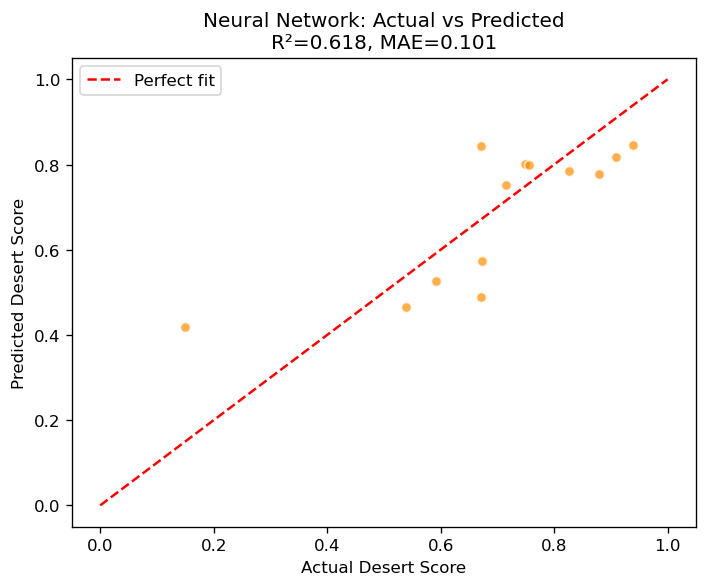

In [43]:
y_pred_nn = nn_best.predict(X_test_sc)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y_test, y_pred_nn, alpha=0.7, edgecolors='white', color='darkorange')
ax.plot([0, 1], [0, 1], 'r--', lw=1.5, label='Perfect fit')
ax.set_xlabel('Actual Desert Score')
ax.set_ylabel('Predicted Desert Score')
ax.set_title(f'Neural Network: Actual vs Predicted\nR²={test_r2_nn:.3f}, MAE={mae_nn:.3f}')
ax.legend()
plt.tight_layout()
plt.savefig('nn_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

The Neural Network outperformed the Random Forest on the test set, achieving
R² = 0.618 and MAE = 0.101. The optimal architecture and activation function selected by grid search are printed in the output above. The scatter plot sits noticeably closer to the perfect fit line than the 
Random Forest, particularly for districts with desert scores above 0.6, 
where the RF consistently underestimated. At the lower end of the scale 
(scores below 0.3), both models show similar scatter, suggesting that 
distinguishing well-served districts from moderately served ones is harder 
than identifying the most underserved. The architecture selected by grid 
search reflects the dataset size: a larger network would overfit on 62 observations.

#### Model Comparison:

In [44]:
# compare CV, train, and test R-squared across both models
results_df = pd.DataFrame({
    'Model':      ['Random Forest', 'Neural Network'],
    'CV_R2':      [round(rf_results['CV_R2'],    3), round(nn_results['CV_R2'],    3)],
    'Train_R2':   [round(rf_results['Train_R2'], 3), round(nn_results['Train_R2'], 3)],
    'Test_R2':    [round(rf_results['Test_R2'],  3), round(nn_results['Test_R2'],  3)],
    'Test_MAE':   [round(rf_results['Test_MAE'], 3), round(nn_results['Test_MAE'], 3)]
})
print(results_df.to_string(index=False))

         Model  CV_R2  Train_R2  Test_R2  Test_MAE
 Random Forest -0.107     0.513    0.446     0.102
Neural Network -0.827     0.427    0.618     0.101


Both models returned negative cross-validation R² scores (Random Forest:
-0.107, Neural Network: -0.827). A negative R² means the model performed
worse than simply predicting the mean desert score for every district.
This is a known limitation of applying cross-validation to small datasets,
where each training fold contains too few samples for stable generalisation
(Arlot and Celisse, 2010). With roughly 39 to 49 observations per training
fold here, the test set results are the more reliable performance indicator.

### 5.4 Method 3: Permutation Feature Importance:

      Feature  Importance      Std
  pct_elderly    0.032053 0.038166
  pop_density    0.080890 0.089472
median_income    0.179858 0.124637
     pct_snap    0.180876 0.111842


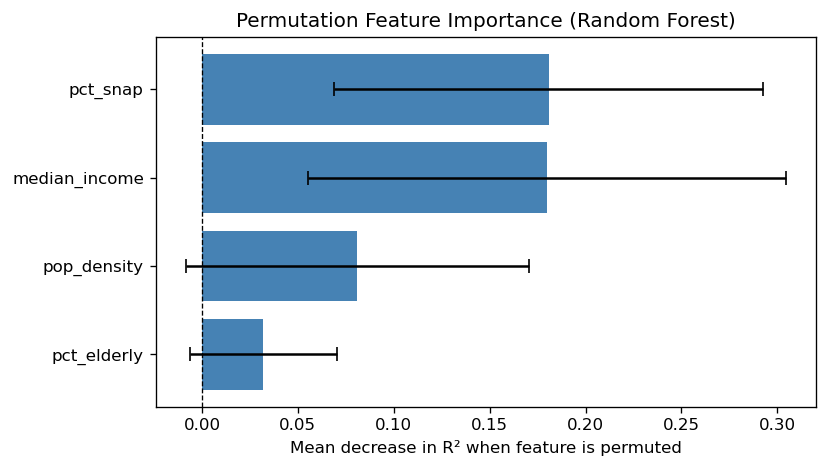

In [45]:
# permutation importance on best model (Random Forest)
perm = permutation_importance(rf_best, X_test, y_test, n_repeats=30, random_state=42, n_jobs=-1)

perm_df = pd.DataFrame({
    'Feature':    FEATURES,
    'Importance': perm.importances_mean,
    'Std':        perm.importances_std
}).sort_values('Importance', ascending=True)

print(perm_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(perm_df['Feature'], perm_df['Importance'],
        xerr=perm_df['Std'], color='steelblue', capsize=4)
ax.axvline(0, color='black', lw=0.8, ls='--')
ax.set_xlabel('Mean decrease in R² when feature is permuted')
ax.set_title('Permutation Feature Importance (Random Forest)')
plt.tight_layout()
plt.savefig('permutation_importance.png', dpi=150, bbox_inches='tight')
plt.show()

SNAP recipiency (pct_snap = 0.181) and median income (median_income = 0.180)
ranked as near-equal top predictors, with population density third (0.081)
and the elderly share lowest (0.032). The wide error bars on the top two
features reflect that they are correlated, causing the model to distribute
predictive credit unevenly between them across the 30 repeats. Together,
both variables point clearly to economic deprivation as the dominant spatial
driver of desert status. This aligns with the borough-level pattern reported
by NYCEDC (2020), where Manhattan has double the healthcare workers per
100 residents compared to the Bronx, Queens and Staten Island, with only
52% of primary care facilities located outside Manhattan and Brooklyn.
The weak contribution of the elderly share suggests that in NYC, age alone
does not reliably predict where facilities are scarce at the community
district level.

### 5.5 Method 4: SHAP

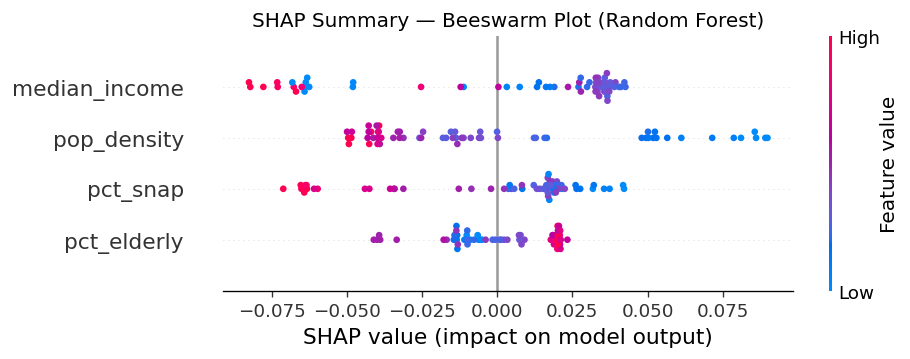

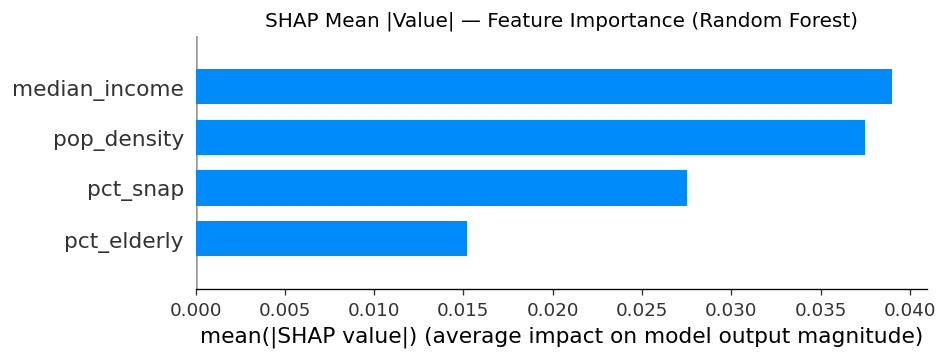

In [46]:
# SHAP interpretation on Random Forest (TreeExplainer - exact and fast)
explainer   = shap.TreeExplainer(rf_best)
shap_values = explainer.shap_values(X)
X_df        = pd.DataFrame(X, columns=FEATURES)

# beeswarm plot
plt.figure(figsize=(9, 5))
shap.summary_plot(shap_values, X_df, show=False)
plt.title('SHAP Summary — Beeswarm Plot (Random Forest)')
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

# bar plot
plt.figure(figsize=(7, 4))
shap.summary_plot(shap_values, X_df, plot_type='bar', show=False)
plt.title('SHAP Mean |Value| — Feature Importance (Random Forest)')
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

The SHAP bar chart ranks median_income first (mean |SHAP| ≈ 0.038), followed
by pop_density (0.036), pct_snap (0.026) and pct_elderly (0.016). This
differs slightly from the permutation rankings because SHAP draws on all
62 districts rather than the 13-district test split, making it a more stable
estimate here. The beeswarm plot confirms the expected direction for income:
low-income districts consistently receive positive SHAP values, pushing
predicted desert scores upward. High population density shows a mixed effect,
spreading across both sides of zero. This likely reflects that some of NYC's
densest community districts are also among its most economically deprived,
meaning density does not uniformly improve access. The pct_elderly values
cluster tightly near zero, consistent with its low permutation importance.

Geographically, Bronx community districts, characterised by low median 
incomes and high SNAP recipiency, consistently appear at the high-SHAP 
end of the beeswarm plot, receiving the largest positive contributions 
from both economic features and the highest predicted desert scores, 
directly linking the model's feature attributions back to the borough-level 
inequalities documented in the Introduction.

## 6. Conclusion

[[ go back to the top ]](#Table-of-contents)

Socioeconomic characteristics substantially predict the spatial distribution of primary care deserts across NYC's community districts, with economic deprivation, measured by median income and SNAP recipiency, explaining the dominant share of spatial variation. Two supervised regression models were trained on four census-derived features and two interpretability methods were applied to move beyond prediction toward explanation.

The Neural Network outperformed the Random Forest, explaining 62% of variance in desert scores against 45%. Both models reproduced a recognisable borough-level economic gradient in their spatial predictions. Moderate overall accuracy reflects the genuine constraint of predicting access inequality from four sociodemographic features across 62 districts. Permutation importance and SHAP analysis converged on the same finding: economic deprivation is the dominant spatial predictor of primary care desert status. Median household income and SNAP recipiency ranked as the two strongest predictors across both methods. Population density exerted a secondary and directionally mixed effect. The elderly share contributed least to model predictions. This pattern is consistent with borough-level evidence that the most economically deprived districts in the Bronx and outer boroughs face the steepest facility shortages. Morever, this study has two key limitations. First, only 62 community districts are available, constraining model stability and the reliability of cross-validation estimates. Second, the desert score captures facility count per capita but not facility capacity, opening hours, or whether residents are insured, all of which affect realised access.

Overall, the findings indicate that sociodemographic characteristics do largely predict the spatial distribution of primary care deserts and the predictive signal is concentrated in economic variables. Future research should expand the feature set to include insurance coverage and transit accessibility to capture dimensions of access that sociodemographic proxies cannot fully represent. At the policy level, priority investment should be directed toward the lowest-income community districts where the economic gradient identified here is steepest.

## References

[[ go back to the top ]](#Table-of-contents)